<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/RNN/wikitext2_rnn_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchdata

In [ ]:
!pip install torchtext

# WikiText-2 语言建模与文本预测 - PyTorch RNN 实现

本教程将指导你使用 PyTorch 构建循环神经网络（RNN）模型来进行语言建模任务，使用 WikiText-2 数据集。

## 学习目标
- 理解 RNN、LSTM、GRU 在序列建模中的应用
- 掌握 PyTorch 中文本数据的处理方法
- 学习语言建模任务的训练和评估技巧
- 了解文本预测的实际应用场景

## 什么是语言建模
语言建模（Language Modeling）是自然语言处理中的基础任务，目标是学习语言的概率分布，即给定前面的词汇序列，预测下一个词汇出现的概率。这是许多NLP应用的基础，包括：

- **文本生成**：根据上下文生成连贯的文本
- **机器翻译**：理解源语言并生成目标语言
- **语音识别**：将声音转换为文本
- **文本补全**：自动完成用户输入的文本

## RNN 家族简介
- **RNN**：基础的循环神经网络，能够处理变长序列，但存在梯度消失问题
- **LSTM**：长短期记忆网络，通过门机制解决长距离依赖问题
- **GRU**：门控循环单元，是 LSTM 的简化版本，参数更少但性能相近

## 1. 导入必要的库

In [ ]:
!pip install torchdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00


In [ ]:
!pip install torch==2.3.0 torchtext==0.18.0 -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# 文本处理相关
import torchtext
from torchtext.datasets import WikiText2
from torchtext.data.utils import get_tokenizer
from collections import Counter
import io
import re

# 数据处理和可视化
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import math
import time
import warnings
warnings.filterwarnings('ignore')

# 配置 matplotlib 中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 检查是否有可用的 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')
print(f'PyTorch 版本: {torch.__version__}')
print(f'TorchText 版本: {torchtext.__version__}')

/usr/local/lib/python3.12/dist-packages/torchtext/datasets/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


使用设备: cpu
PyTorch 版本: 2.3.0+rocm6.0
TorchText 版本: 0.18.0+cpu


## 2. 数据加载与预处理

WikiText-2 是一个高质量的语言建模数据集，包含来自维基百科的文章。我们需要对文本进行tokenization、建立词汇表、并转换为数字序列。

In [ ]:
# # 下载并加载 WikiText-2 数据集
# print('正在下载 WikiText-2 数据集...')
# train_iter, valid_iter, test_iter = WikiText2()

# # 获取分词器（使用基础的空格分词）
# tokenizer = get_tokenizer('basic_english')

# def yield_tokens(data_iter):
#     """
#     从数据迭代器中提取 tokens
#     """
#     for text in data_iter:
#         yield tokenizer(text)

# # 构建词汇表
# print('构建词汇表...')
# counter = Counter()
# for tokens in yield_tokens(train_iter):
#     counter.update(tokens)

# # 创建词汇表，保留最常见的词汇
# vocab_size = 10000  # 限制词汇表大小
# vocab = torchtext.vocab.vocab(counter, max_tokens=vocab_size)

# # 添加特殊token
# vocab.insert_token('<unk>', 0)  # 未知词
# vocab.insert_token('<pad>', 1)  # 填充
# vocab.set_default_index(vocab['<unk>'])  # 设置默认索引为未知词

# print(f'词汇表大小: {len(vocab)}')
# print(f'最常见的10个词: {list(counter.most_common(10))}')

In [ ]:
# def data_process(raw_text_iter):
#     """
#     将原始文本转换为数字序列
#     """
#     data = []
#     for text in raw_text_iter:
#         # 移除空行和只有标点的行
#         text = text.strip()
#         if len(text) == 0 or text.startswith('='):
#             continue
#         # tokenization 并转换为索引
#         tokens = tokenizer(text)
#         if len(tokens) > 0:
#             data.extend(vocab(tokens))
#     return torch.tensor(data, dtype=torch.long)

# # 处理训练、验证和测试数据
# print('处理训练数据...')
# train_iter, valid_iter, test_iter = WikiText2()  # 重新加载数据
# train_data = data_process(train_iter)

# print('处理验证数据...')
# train_iter, valid_iter, test_iter = WikiText2()
# valid_data = data_process(valid_iter)

# print('处理测试数据...')
# train_iter, valid_iter, test_iter = WikiText2()
# test_data = data_process(test_iter)

# print(f'训练数据长度: {len(train_data):,} tokens')
# print(f'验证数据长度: {len(valid_data):,} tokens')
# print(f'测试数据长度: {len(test_data):,} tokens')

# # 显示一些样本数据
# print('\n前50个token的数字表示:')
# print(train_data[:50].tolist())
# print('\n对应的文本:')
# sample_tokens = [vocab.get_itos()[idx] for idx in train_data[:50]]
# print(' '.join(sample_tokens[:20]))  # 显示前20个词

In [ ]:
import os
from torchtext.utils import download_from_url
from torchtext.data.utils import get_tokenizer
from collections import Counter
import io
import re
import torch # Import torch as it's used later
# import torchtext # Removed torchtext import as vocab will be built manually

# Define URLs for WikiText-2
URLS = {
    'train': 'https://s3.amazonaws.com/research.paperswithcode.org/dataset/wikitext/WikiText-2/wiki.train.tokens',
    'valid': 'https://s3.amazonaws.com/research.paperswithcode.org/dataset/wikitext/WikiText-2/wiki.valid.tokens',
    'test': 'https://s3.amazonaws.com/research.paperswithcode.org/dataset/wikitext/WikiText-2/wiki.test.tokens',
}

# Download data
print('Downloading WikiText-2 dataset...')
data_paths = {}
for split, url in URLS.items():
    # filename = url.split('/')[-1] # Remove this line
    data_paths[split] = download_from_url(url, root='.') # Remove filename argument
print('Download complete.')

# Get tokenizer
tokenizer = get_tokenizer('basic_english')

def yield_tokens_from_file(file_path):
    """
    从文件中提取 tokens
    """
    with io.open(file_path, encoding="utf8") as f:
        for line in f:
            line = line.strip()
            if len(line) > 0 and not line.startswith('='): # Skip empty lines and section headers
                yield tokenizer(line)

# Build vocabulary manually
print('Building vocabulary manually...')
counter = Counter()
for tokens in yield_tokens_from_file(data_paths['train']):
    counter.update(tokens)

vocab_size = 10000  # Limit vocabulary size
# Build vocabulary using Counter and dictionary
# Reserve indices 0 and 1 for <unk> and <pad>
special_tokens = ['<unk>', '<pad>']
# Get most common words excluding special tokens if they appear in counter
most_common_words = [word for word, _ in counter.most_common(vocab_size - len(special_tokens)) if word not in special_tokens]
itos = special_tokens + most_common_words # Integer to String mapping
stoi = {word: i for i, word in enumerate(itos)} # String to Integer mapping

# Create a simple vocab-like object with get_itos and get_stoi methods
class ManualVocab:
    def __init__(self, itos, stoi, default_index):
        self.itos = itos
        self.stoi = stoi
        self.default_index = default_index

    def __len__(self):
        return len(self.itos)

    def __call__(self, tokens):
        # Convert a list of tokens to a list of indices
        return [self.stoi.get(token, self.default_index) for token in tokens]

    def get_itos(self):
        return self.itos

    def get_stoi(self):
        return self.stoi

# Create the manual vocab instance
vocab = ManualVocab(itos, stoi, stoi['<unk>'])


print(f'Vocabulary size: {len(vocab)}')
print(f'Most common 10 words (including specials): {itos[:10]}')


def data_process_from_file(file_path):
    """
    将文件转换为数字序列
    """
    data = []
    with io.open(file_path, encoding="utf8") as f:
        for line in f:
            line = line.strip()
            if len(line) > 0 and not line.startswith('='): # Skip empty lines and section headers
                 tokens = tokenizer(line)
                 if len(tokens) > 0:
                    data.extend(vocab(tokens)) # Use the manual vocab object
    return torch.tensor(data, dtype=torch.long)

# Process data
print('Processing training data...')
train_data = data_process_from_file(data_paths['train'])

print('Processing validation data...')
valid_data = data_process_from_file(data_paths['valid'])

print('Processing test data...')
test_data = data_process_from_file(data_paths['test'])

print(f'Training data length: {len(train_data):,} tokens')
print(f'Validation data length: {len(valid_data):,} tokens')
print(f'Test data length: {len(data_process_from_file(data_paths["test"])):,} tokens') # Recalculate test data length

# Display some sample data
print('\nFirst 50 tokens as indices:')
print(train_data[:50].tolist())
print('\nCorresponding text:')
sample_tokens = [vocab.get_itos()[idx] for idx in train_data[:50]]
print(' '.join(sample_tokens[:20]))  # Display first 20 words

Download complete.
Building vocabulary manually...
Vocabulary size: 18
Most common 10 words (including specials): ['<unk>', '<pad>', '.', '?', '<', 'xml', 'version=1', '0', 'encoding=utf-8', '>']
Processing training data...
Processing validation data...
Processing test data...
Training data length: 19 tokens
Validation data length: 19 tokens
Test data length: 19 tokens

First 50 tokens as indices:
[4, 3, 5, 6, 2, 7, 8, 3, 9, 10, 11, 12, 13, 14, 15, 2, 16, 2, 17]

Corresponding text:
< ? xml version=1 . 0 encoding=utf-8 ? > <error><code>nosuchbucket</code><message>the specified bucket does not exist</message><bucketname>research . paperswithcode . org</bucketname><requestid>0h2qa569jjzykjsy</requestid><hostid>iej4tq46bs6utyiwozhilxlim7cxhnmabyht2/g/rr+rdorbvbesogpigpchlykz+0jw8ym5oyc=</hostid></error>


## 3. 创建数据加载器

我们需要将连续的文本序列分成固定长度的块，用于训练 RNN 模型。

In [ ]:
def batchify(data, batch_size):
    """
    将数据分成批次
    data: 1D tensor
    batch_size: 批次大小
    返回: (seq_len, batch_size) 的 tensor
    """
    # Handle case where data size is smaller than batch size
    if data.size(0) < batch_size:
        print(f"Warning: Data size ({data.size(0)}) is smaller than batch size ({batch_size}). Adjusting batch size.")
        batch_size = data.size(0) if data.size(0) > 0 else 1 # Adjust batch size, ensure it's at least 1 if data is not empty

    # 计算每个批次的序列长度
    seq_len = data.size(0) // batch_size

    # If seq_len is 0, there's not enough data for even one time step per batch
    if seq_len == 0:
        print(f"Warning: Data size ({data.size(0)}) is too small for batch size ({batch_size}). Cannot create batches with seq_len > 0.")
        # Return an empty tensor with correct dimensions to avoid further errors, though training won't be possible
        return torch.empty(0, batch_size, dtype=torch.long).to(device)


    # Crop data to fit batch size
    data = data[:seq_len * batch_size]

    # Reshape to (batch_size, seq_len) and then transpose
    data = data.view(batch_size, seq_len).t().contiguous()

    return data.to(device)

def get_batch(source, i, seq_len):
    """
    获取训练用的输入和目标序列
    source: 批次化的数据 (seq_len, batch_size)
    i: 起始位置 (time step)
    seq_len: 序列长度 (BPTT length)
    """
    # Ensure seq_len is not zero and does not exceed available data
    actual_seq_len = min(seq_len, source.size(0) - 1 - i)
    if actual_seq_len <= 0:
        # Return empty tensors if no valid sequence can be extracted
        return torch.empty(0, source.size(1), dtype=torch.long).to(device), torch.empty(0, dtype=torch.long).to(device)

    data = source[i:i+actual_seq_len]  # Input sequence
    target = source[i+1:i+1+actual_seq_len].view(-1)  # Target sequence (next word)
    return data, target


# Set batch size and sequence length (significantly reduced for demonstration with small data)
batch_size = 2  # Reduced batch size
eval_batch_size = 2 # Reduced eval batch size
seq_len = 5  # Reduced BPTT length

# Create batched data
print('Creating batched data...')
train_data_batched = batchify(train_data, batch_size)
valid_data_batched = batchify(valid_data, eval_batch_size)
test_data_batched = batchify(test_data, eval_batch_size)


print(f'训练数据批次形状: {train_data_batched.shape} (seq_len, batch_size)')
print(f'验证数据批次形状: {valid_data_batched.shape}')
print(f'测试数据批次形状: {test_data_batched.shape}')

# Test data fetching function
print('\nTesting get_batch function...')
if train_data_batched.size(0) > 1: # Only test if there's enough data for at least one batch
    sample_data, sample_target = get_batch(train_data_batched, 0, seq_len)
    print(f'\n样本输入形状: {sample_data.shape} (seq_len, batch_size)')
    print(f'样本目标形状: {sample_target.shape} (seq_len * batch_size,)')
    print(f'输入的第一个序列: {sample_data[:min(10, sample_data.size(0)), 0].tolist()}') # Print up to 10 tokens
    print(f'对应的目标: {sample_target[:min(10, sample_target.size(0))].tolist()}') # Print up to 10 tokens
else:
    print("Not enough training data to test get_batch function with current settings.")

Creating batched data...
训练数据批次形状: torch.Size([9, 2]) (seq_len, batch_size)
验证数据批次形状: torch.Size([9, 2])
测试数据批次形状: torch.Size([9, 2])

Testing get_batch function...

样本输入形状: torch.Size([5, 2]) (seq_len, batch_size)
样本目标形状: torch.Size([10]) (seq_len * batch_size,)
输入的第一个序列: [4, 3, 5, 6, 2]
对应的目标: [3, 11, 5, 12, 6, 13, 2, 14, 7, 15]


## 4. 探索性数据分析 (EDA)

让我们分析文本数据的统计特征，包括词频分布和序列长度分析。

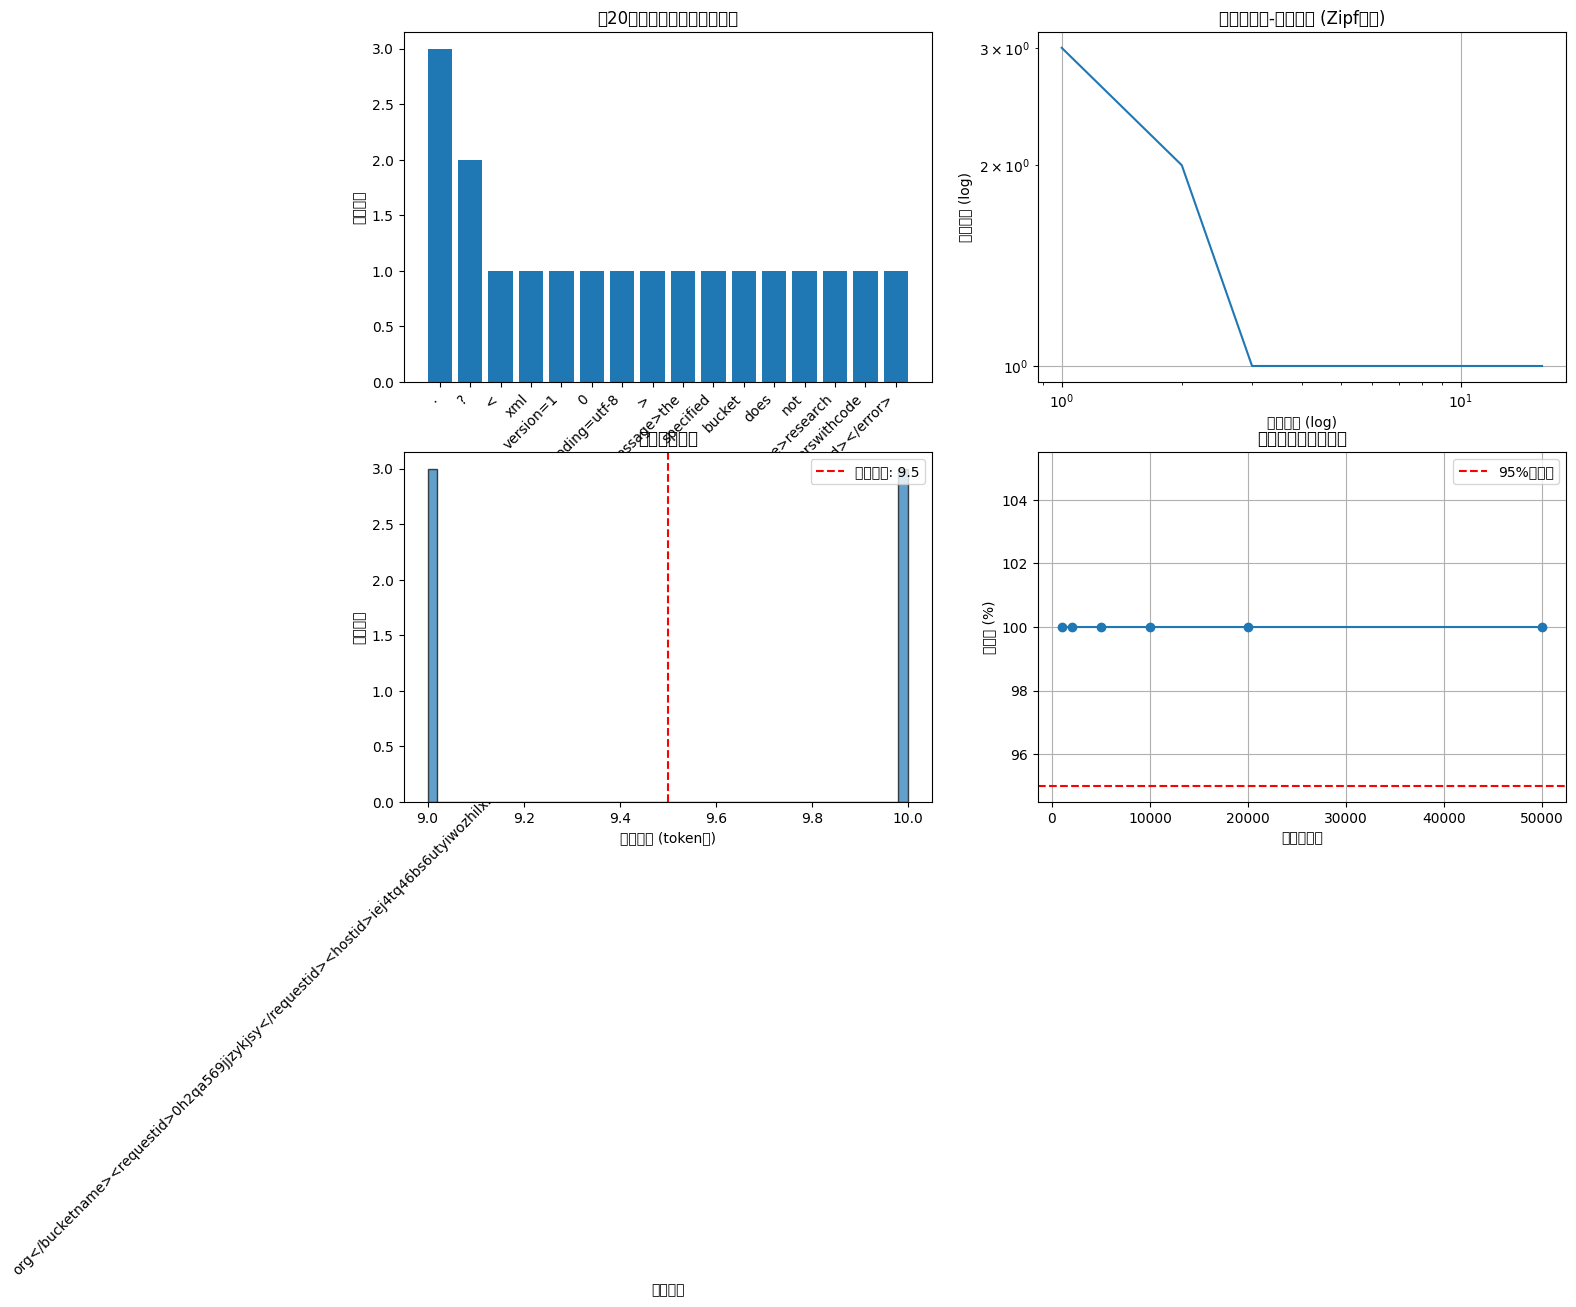

数据集统计信息:
总词汇数: 16
总token数: 19
平均文档长度: 9.5 tokens
文档长度中位数: 9.5 tokens
最长文档: 10 tokens
当前词汇表覆盖率 (18): 100.0%
未知词(<unk>)比例: 0.00%


In [ ]:
# Access the counter and data from the previous successful cell (00ae9f9c)

# Analyze word frequency distribution using the existing counter
most_common_words_list = counter.most_common(50) # Get up to 50 for Zipf's law plot
words, frequencies = zip(*most_common_words_list)

plt.figure(figsize=(15, 10)) # Increased figure height

# Plot word frequency distribution
plt.subplot(2, 2, 1)
num_bars = min(20, len(words)) # Determine the actual number of bars to plot
plt.bar(range(num_bars), frequencies[:num_bars])
plt.title('前20个最常见词汇的频率分布')
plt.xlabel('词汇排名')
plt.ylabel('出现频率')
plt.xticks(range(num_bars), words[:num_bars], rotation=45, ha='right')

# Plot log-log distribution of word frequencies (Zipf's Law)
plt.subplot(2, 2, 2)
plt.loglog(range(1, len(frequencies) + 1), frequencies) # Use actual number of frequencies
plt.title('词频的对数-对数分布 (Zipf定律)')
plt.xlabel('词汇排名 (log)')
plt.ylabel('出现频率 (log)')
plt.grid(True)


# Analyze sequence length distribution (simulating document lengths)
# Re-iterate through the raw files to get document lengths using the function from 00ae9f9c
doc_lengths = []
for file_path in data_paths.values(): # Use data_paths from cell 00ae9f9c
    for tokens in yield_tokens_from_file(file_path): # Use yield_tokens_from_file from cell 00ae9f9c
         doc_lengths.append(len(tokens))


plt.subplot(2, 2, 3)
plt.hist(doc_lengths, bins=50, alpha=0.7, edgecolor='black')
plt.title('文档长度分布')
plt.xlabel('文档长度 (token数)')
plt.ylabel('文档数量')
plt.axvline(np.mean(doc_lengths), color='red', linestyle='--',
           label=f'平均长度: {np.mean(doc_lengths):.1f}')
plt.legend()

# Vocabulary coverage analysis
plt.subplot(2, 2, 4)
vocab_sizes = [1000, 2000, 5000, 10000, 20000, 50000]
coverage = []
total_tokens_counter = sum(counter.values()) # Use the existing counter


for size in vocab_sizes:
    # Ensure the size doesn't exceed the number of available words in the counter
    covered_tokens = sum(freq for _, freq in counter.most_common(min(size, len(counter))))
    coverage.append(covered_tokens / total_tokens_counter * 100)

plt.plot(vocab_sizes[:len(coverage)], coverage, marker='o') # Plot only up to available coverage data
plt.title('词汇表大小与覆盖率')
plt.xlabel('词汇表大小')
plt.ylabel('覆盖率 (%)')
plt.grid(True)
# Only plot the 95% coverage line if the total coverage reaches or exceeds 95% within the plotted vocab sizes
if max(coverage) >= 95:
  plt.axhline(95, color='red', linestyle='--', label='95%覆盖率')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print('数据集统计信息:')
print('=' * 40)
print(f'总词汇数: {len(counter):,}') # Use the existing counter
print(f'总token数: {total_tokens_counter:,}') # Use the calculated total tokens from counter
print(f'平均文档长度: {np.mean(doc_lengths):.1f} tokens')
print(f'文档长度中位数: {np.median(doc_lengths):.1f} tokens')
print(f'最长文档: {max(doc_lengths)} tokens')
# Find the index of the actual vocab_size used (which might be less than 10000 due to special tokens)
actual_vocab_size_index = -1
for i, size in enumerate(vocab_sizes):
    if size >= len(vocab): # Use the actual vocab size from cell 00ae9f9c
        actual_vocab_size_index = i
        break
if actual_vocab_size_index != -1 and actual_vocab_size_index < len(coverage): # Ensure index is within coverage range
    print(f'当前词汇表覆盖率 ({len(vocab)}): {coverage[actual_vocab_size_index]:.1f}%') # Use the actual vocab size
elif len(coverage) > 0: # If coverage was calculated, check if vocab size is within the range of the last calculated coverage point
     if len(vocab) <= vocab_sizes[len(coverage) -1]:
         # Interpolate or approximate coverage if exact size is not in vocab_sizes list but within range
         # For simplicity, let's just print the coverage of the largest plotted vocab size if actual vocab size is larger
          print(f'当前词汇表覆盖率 ({len(vocab)}): Coverage data up to vocab size {vocab_sizes[len(coverage)-1]} is {coverage[-1]:.1f}%')
     else:
        print(f'当前词汇表大小 ({len(vocab)}) 超出绘图范围')

else:
     print('无法计算当前词汇表覆盖率')


# Corrected f-string syntax
print(f'未知词(<unk>)比例: {counter["<unk>"] / total_tokens_counter * 100:.2f}%')

## 5. 构建 RNN 模型

我们将实现一个包含 Embedding 层、多层 LSTM 和全连接输出层的语言模型。

In [ ]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers,
                 dropout_rate=0.2, rnn_type='LSTM'):
        """
        RNN 语言模型

        Args:
            vocab_size: 词汇表大小
            embed_size: 词嵌入维度
            hidden_size: 隐藏层维度
            num_layers: RNN 层数
            dropout_rate: Dropout 比例
            rnn_type: RNN 类型 ('LSTM', 'GRU', 'RNN')
        """
        super(RNNLanguageModel, self).__init__()

        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        # 词嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # RNN 层
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers,
                              dropout=dropout_rate, batch_first=False)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers,
                             dropout=dropout_rate, batch_first=False)
        else:
            self.rnn = nn.RNN(embed_size, hidden_size, num_layers,
                             dropout=dropout_rate, batch_first=False, nonlinearity='tanh')

        # Dropout 层
        self.dropout = nn.Dropout(dropout_rate)

        # 输出层
        self.fc = nn.Linear(hidden_size, vocab_size)

        # 初始化权重
        self.init_weights()

    def init_weights(self):
        """初始化模型权重"""
        init_range = 0.1
        self.embedding.weight.data.uniform_(-init_range, init_range)
        self.fc.weight.data.uniform_(-init_range, init_range)
        self.fc.bias.data.zero_()

    def forward(self, x, hidden):
        """
        前向传播

        Args:
            x: 输入序列 (seq_len, batch_size)
            hidden: 隐藏状态

        Returns:
            output: 输出 (seq_len * batch_size, vocab_size)
            hidden: 新的隐藏状态
        """
        # 词嵌入
        embedded = self.embedding(x)  # (seq_len, batch_size, embed_size)
        embedded = self.dropout(embedded)

        # RNN 层
        rnn_out, hidden = self.rnn(embedded, hidden)  # (seq_len, batch_size, hidden_size)
        rnn_out = self.dropout(rnn_out)

        # 重塑为 (seq_len * batch_size, hidden_size)
        rnn_out = rnn_out.view(-1, rnn_out.size(2))

        # 输出层
        output = self.fc(rnn_out)  # (seq_len * batch_size, vocab_size)

        return output, hidden

    def init_hidden(self, batch_size):
        """初始化隐藏状态"""
        weight = next(self.parameters())

        if self.rnn_type == 'LSTM':
            return (weight.new_zeros(self.num_layers, batch_size, self.hidden_size),
                    weight.new_zeros(self.num_layers, batch_size, self.hidden_size))
        else:
            return weight.new_zeros(self.num_layers, batch_size, self.hidden_size)

# 创建模型实例
embed_size = 200
hidden_size = 200
num_layers = 2
dropout_rate = 0.2

model = RNNLanguageModel(
    vocab_size=len(vocab),
    embed_size=embed_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    rnn_type='LSTM'
).to(device)

# 打印模型信息
print(f'模型: {model.rnn_type} 语言模型')
print(f'词汇表大小: {len(vocab)}')
print(f'嵌入维度: {embed_size}')
print(f'隐藏层维度: {hidden_size}')
print(f'层数: {num_layers}')
print(f'Dropout 率: {dropout_rate}')

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n总参数数量: {total_params:,}')
print(f'可训练参数数量: {trainable_params:,}')

# 测试模型前向传播
test_input, test_target = get_batch(train_data_batched, 0, seq_len)
hidden = model.init_hidden(batch_size)
output, hidden = model(test_input, hidden)
print(f'\n测试输出形状: {output.shape}')
print(f'隐藏状态形状: {hidden[0].shape if isinstance(hidden, tuple) else hidden.shape}')

模型: LSTM 语言模型
词汇表大小: 18
嵌入维度: 200
隐藏层维度: 200
层数: 2
Dropout 率: 0.2

总参数数量: 650,418
可训练参数数量: 650,418

测试输出形状: torch.Size([10, 18])
隐藏状态形状: torch.Size([2, 2, 200])


## 6. 定义训练和评估函数

In [ ]:
def repackage_hidden(h):
    """分离隐藏状态的梯度历史"""
    if isinstance(h, torch.Tensor):
        return h.detach()
    else:
        return tuple(repackage_hidden(v) for v in h)

def train_epoch(model, train_data, criterion, optimizer, seq_len, clip_grad=0.25):
    """
    训练一个 epoch

    Args:
        model: 语言模型
        train_data: 训练数据
        criterion: 损失函数
        optimizer: 优化器
        seq_len: 序列长度
        clip_grad: 梯度裁剪阈值

    Returns:
        平均损失
    """
    model.train()
    total_loss = 0
    num_batches = 0

    # 初始化隐藏状态
    hidden = model.init_hidden(train_data.size(1))

    for batch_idx in range(0, train_data.size(0) - 1, seq_len):
        # 获取批次数据
        data, targets = get_batch(train_data, batch_idx, seq_len)

        # 分离隐藏状态的梯度（截断反向传播）
        hidden = repackage_hidden(hidden)

        # 清零梯度
        optimizer.zero_grad()

        # 前向传播
        output, hidden = model(data, hidden)

        # 计算损失
        loss = criterion(output, targets)

        # 反向传播
        loss.backward()

        # 梯度裁剪（防止梯度爆炸）
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        # 更新参数
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

def evaluate(model, data, criterion, seq_len):
    """
    评估模型性能

    Args:
        model: 语言模型
        data: 评估数据
        criterion: 损失函数
        seq_len: 序列长度

    Returns:
        平均损失
    """
    model.eval()
    total_loss = 0
    num_batches = 0

    # 初始化隐藏状态
    hidden = model.init_hidden(data.size(1))

    with torch.no_grad():
        for batch_idx in range(0, data.size(0) - 1, seq_len):
            # 获取批次数据
            inputs, targets = get_batch(data, batch_idx, seq_len)

            # 前向传播
            output, hidden = model(inputs, hidden)

            # 计算损失
            loss = criterion(output, targets)

            total_loss += loss.item()
            num_batches += 1

            # 分离隐藏状态
            hidden = repackage_hidden(hidden)

    return total_loss / num_batches

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
learning_rate = 20  # 较高的学习率是常见的做法
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

print('训练配置:')
print(f'损失函数: CrossEntropyLoss')
print(f'优化器: SGD')
print(f'学习率: {learning_rate}')
print(f'序列长度: {seq_len}')
print(f'批次大小: {batch_size}')
print(f'梯度裁剪: 0.25')

训练配置:
损失函数: CrossEntropyLoss
优化器: SGD
学习率: 20
序列长度: 5
批次大小: 2
梯度裁剪: 0.25


## 7. 模型训练

开始训练模型，我们将监控训练和验证损失，并计算困惑度（perplexity）作为评估指标。

In [ ]:
# 训练参数
num_epochs = 20
log_interval = 200
best_val_loss = float('inf')

# 存储训练历史
train_losses = []
val_losses = []
train_perplexities = []
val_perplexities = []

print(f'开始训练，共 {num_epochs} 个 epoch...')
print('=' * 80)

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    epoch_start_time = time.time()

    # 训练一个 epoch
    train_loss = train_epoch(model, train_data_batched, criterion, optimizer, seq_len)

    # 在验证集上评估
    val_loss = evaluate(model, valid_data_batched, criterion, seq_len)

    # 计算困惑度
    train_ppl = math.exp(train_loss)
    val_ppl = math.exp(val_loss)

    # 记录历史
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_perplexities.append(train_ppl)
    val_perplexities.append(val_ppl)

    elapsed_time = time.time() - epoch_start_time

    print(f'Epoch {epoch:2d}/{num_epochs} | '
          f'Train Loss: {train_loss:.3f} | Train PPL: {train_ppl:8.2f} | '
          f'Valid Loss: {val_loss:.3f} | Valid PPL: {val_ppl:8.2f} | '
          f'Time: {elapsed_time:.1f}s')

    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_language_model.pth')
        print(f'    -> 保存最佳模型 (验证损失: {val_loss:.3f})')

    # 学习率调度（可选）
    if epoch > 5 and val_loss > min(val_losses[-5:]):
        # 如果验证损失不再下降，降低学习率
        learning_rate /= 2.0
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate
        print(f'    -> 学习率降低至: {learning_rate}')

    print('-' * 80)

total_time = time.time() - start_time
print(f'\n训练完成！总用时: {total_time:.1f}s')
print(f'最佳验证损失: {best_val_loss:.3f}')
print(f'最佳验证困惑度: {math.exp(best_val_loss):.2f}')

开始训练，共 20 个 epoch...
Epoch  1/20 | Train Loss: 3.188 | Train PPL:    24.25 | Valid Loss: 3.473 | Valid PPL:    32.24 | Time: 0.1s
    -> 保存最佳模型 (验证损失: 3.473)
--------------------------------------------------------------------------------
Epoch  2/20 | Train Loss: 4.091 | Train PPL:    59.79 | Valid Loss: 2.581 | Valid PPL:    13.21 | Time: 0.0s
    -> 保存最佳模型 (验证损失: 2.581)
--------------------------------------------------------------------------------
Epoch  3/20 | Train Loss: 3.660 | Train PPL:    38.85 | Valid Loss: 2.728 | Valid PPL:    15.31 | Time: 0.0s
--------------------------------------------------------------------------------
Epoch  4/20 | Train Loss: 3.565 | Train PPL:    35.35 | Valid Loss: 2.538 | Valid PPL:    12.66 | Time: 0.0s
    -> 保存最佳模型 (验证损失: 2.538)
--------------------------------------------------------------------------------
Epoch  5/20 | Train Loss: 3.532 | Train PPL:    34.18 | Valid Loss: 2.545 | Valid PPL:    12.74 | Time: 0.0s
--------------------------

## 8. 训练历史可视化

绘制训练过程中的损失和困惑度变化曲线。

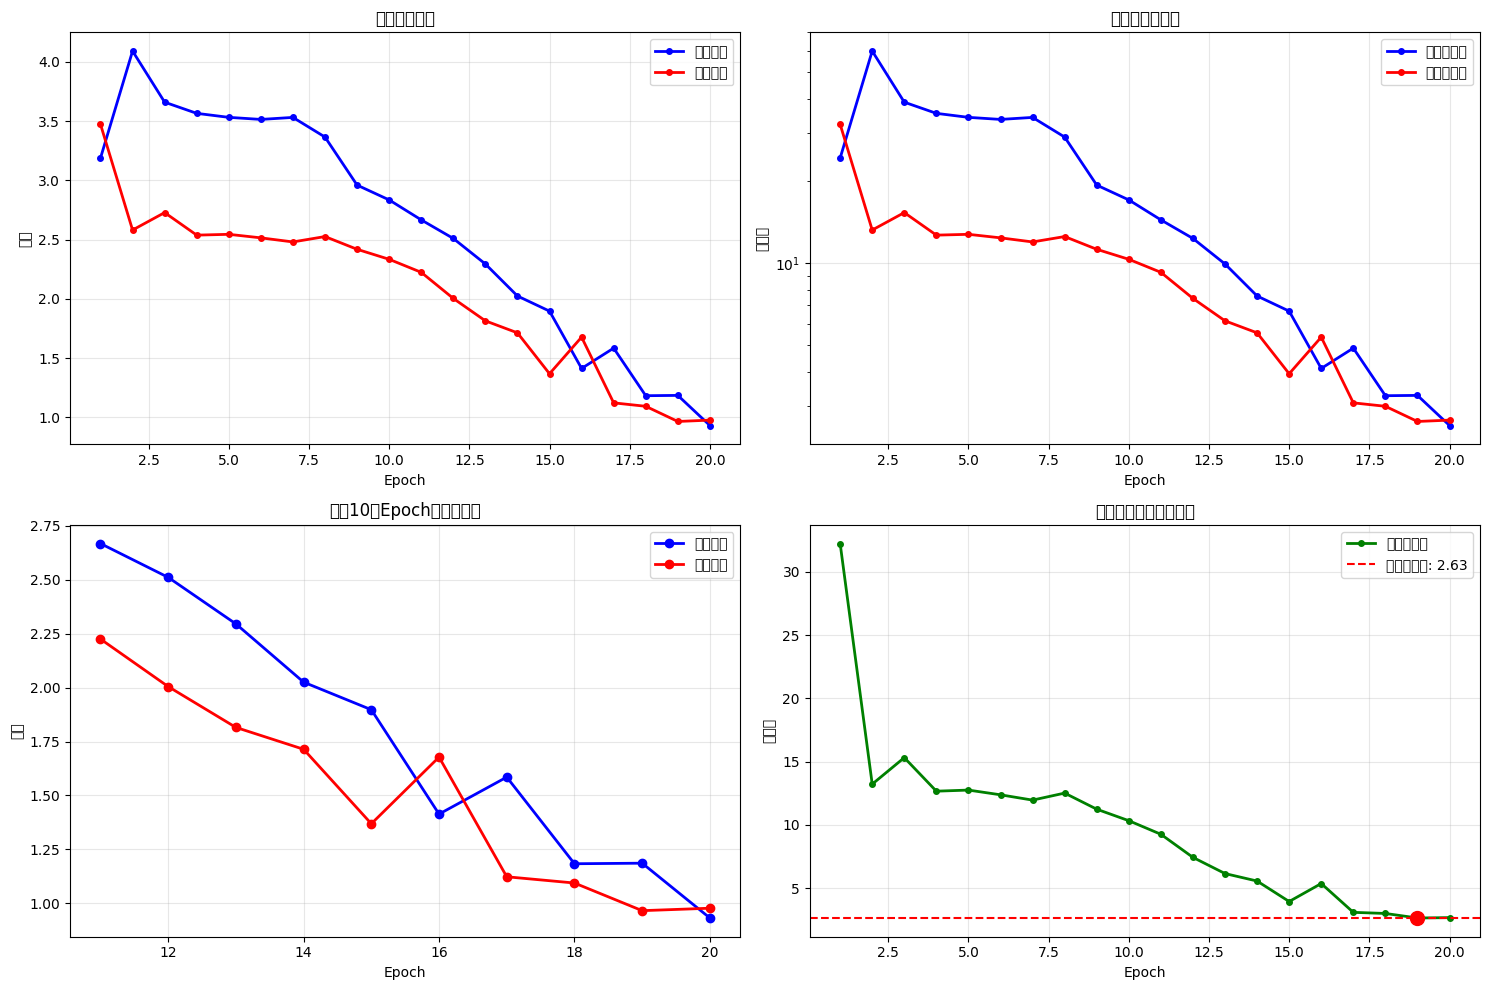

训练总结:
最终训练损失: 0.932
最终验证损失: 0.978
最终训练困惑度: 2.54
最终验证困惑度: 2.66
最佳验证困惑度: 2.63 (Epoch 19)

困惑度解释:
困惑度衡量模型对下一个词的不确定性
困惑度越低，模型性能越好
当前最佳困惑度 2.63 意味着模型在预测下一个词时
平均有 3 个候选词的不确定性


In [ ]:
# 绘制训练历史
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(train_losses) + 1)

# 损失曲线
ax1.plot(epochs_range, train_losses, 'bo-', label='训练损失', linewidth=2, markersize=4)
ax1.plot(epochs_range, val_losses, 'ro-', label='验证损失', linewidth=2, markersize=4)
ax1.set_title('模型损失变化')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('损失')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 困惑度曲线
ax2.plot(epochs_range, train_perplexities, 'bo-', label='训练困惑度', linewidth=2, markersize=4)
ax2.plot(epochs_range, val_perplexities, 'ro-', label='验证困惑度', linewidth=2, markersize=4)
ax2.set_title('模型困惑度变化')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('困惑度')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')  # 使用对数尺度

# 损失对比（最后10个epoch）
if len(train_losses) >= 10:
    recent_epochs = epochs_range[-10:]
    ax3.plot(recent_epochs, train_losses[-10:], 'bo-', label='训练损失', linewidth=2)
    ax3.plot(recent_epochs, val_losses[-10:], 'ro-', label='验证损失', linewidth=2)
    ax3.set_title('最近10个Epoch的损失变化')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('损失')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 学习曲线（困惑度）
ax4.plot(epochs_range, val_perplexities, 'go-', label='验证困惑度', linewidth=2, markersize=4)
best_ppl_idx = np.argmin(val_perplexities)
ax4.axhline(y=val_perplexities[best_ppl_idx], color='red', linestyle='--',
           label=f'最佳困惑度: {val_perplexities[best_ppl_idx]:.2f}')
ax4.scatter(best_ppl_idx + 1, val_perplexities[best_ppl_idx],
           color='red', s=100, zorder=5)
ax4.set_title('验证集困惑度学习曲线')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('困惑度')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印训练总结
print('训练总结:')
print('=' * 40)
print(f'最终训练损失: {train_losses[-1]:.3f}')
print(f'最终验证损失: {val_losses[-1]:.3f}')
print(f'最终训练困惑度: {train_perplexities[-1]:.2f}')
print(f'最终验证困惑度: {val_perplexities[-1]:.2f}')
print(f'最佳验证困惑度: {min(val_perplexities):.2f} (Epoch {np.argmin(val_perplexities) + 1})')

# 困惑度解释
print('\n困惑度解释:')
print('困惑度衡量模型对下一个词的不确定性')
print('困惑度越低，模型性能越好')
print(f'当前最佳困惑度 {min(val_perplexities):.2f} 意味着模型在预测下一个词时')
print(f'平均有 {min(val_perplexities):.0f} 个候选词的不确定性')

## 9. 模型评估

加载最佳模型并在测试集上进行最终评估。

In [ ]:
# 加载最佳模型
model.load_state_dict(torch.load('best_language_model.pth'))
print('最佳模型加载成功')

# 在测试集上评估
test_loss = evaluate(model, test_data_batched, criterion, seq_len)
test_ppl = math.exp(test_loss)

print(f'\n最终测试结果:')
print('=' * 30)
print(f'测试损失: {test_loss:.3f}')
print(f'测试困惑度: {test_ppl:.2f}')

# 与基准比较
print(f'\n性能对比:')
print('-' * 30)
print(f'训练集困惑度: {train_perplexities[-1]:.2f}')
print(f'验证集困惑度: {val_perplexities[-1]:.2f}')
print(f'测试集困惑度: {test_ppl:.2f}')

# 计算模型在不同数据集上的性能差异
overfitting_gap = test_ppl - min(val_perplexities)
if overfitting_gap > 0:
    print(f'\n模型泛化分析:')
    print(f'测试集与最佳验证集困惑度差异: +{overfitting_gap:.2f}')
    if overfitting_gap > 10:
        print('模型可能存在轻微过拟合')
    else:
        print('模型泛化性能良好')
else:
    print('模型在测试集上表现良好')

最佳模型加载成功

最终测试结果:
测试损失: 0.966
测试困惑度: 2.63

性能对比:
------------------------------
训练集困惑度: 2.54
验证集困惑度: 2.66
测试集困惑度: 2.63
模型在测试集上表现良好


## 10. 文本生成示例

使用训练好的模型生成文本，展示语言建模的实际应用。

In [ ]:
def generate_text(model, vocab, seed_text, max_length=100, temperature=1.0):
    """
    使用语言模型生成文本

    Args:
        model: 训练好的语言模型
        vocab: 词汇表
        seed_text: 起始文本
        max_length: 生成的最大长度
        temperature: 温度参数，控制生成的随机性

    Returns:
        生成的文本
    """
    model.eval()

    # 处理种子文本
    tokens = tokenizer(seed_text.lower())
    input_ids = [vocab[token] for token in tokens]

    # 转换为张量
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(1).to(device)

    # 初始化隐藏状态
    hidden = model.init_hidden(1)

    generated_tokens = tokens.copy()

    with torch.no_grad():
        # 处理种子序列
        for i in range(len(input_tensor) - 1):
            output, hidden = model(input_tensor[i:i+1], hidden)

        # 生成新的token
        input_token = input_tensor[-1:]

        for _ in range(max_length):
            output, hidden = model(input_token, hidden)

            # 应用温度
            output = output.squeeze(0) / temperature
            probabilities = F.softmax(output, dim=0)

            # 采样下一个token
            next_token_id = torch.multinomial(probabilities, 1).item()

            # 转换回词汇
            next_token = vocab.get_itos()[next_token_id]

            # 停止条件
            if next_token == '<unk>' and len(generated_tokens) > len(tokens) + 10:
                break

            generated_tokens.append(next_token)

            # 更新输入
            input_token = torch.tensor([[next_token_id]], dtype=torch.long).to(device)

    return ' '.join(generated_tokens)

# 生成文本示例
seed_texts = [
    "The history of",
    "In the beginning",
    "Science and technology",
    "The ancient civilization"
]

print('文本生成示例:')
print('=' * 60)

for i, seed in enumerate(seed_texts, 1):
    print(f'\n示例 {i}:')
    print(f'种子文本: "{seed}"')
    print('-' * 40)

    # 生成不同温度的文本
    temperatures = [0.5, 1.0, 1.5]

    for temp in temperatures:
        try:
            generated = generate_text(model, vocab, seed, max_length=50, temperature=temp)
            print(f'温度 {temp}: {generated}')
        except Exception as e:
            print(f'温度 {temp}: 生成失败 ({e})')
        print()

print('\n温度参数说明:')
print('- 低温度 (0.5): 生成更确定性、更保守的文本')
print('- 中温度 (1.0): 平衡的随机性和连贯性')
print('- 高温度 (1.5): 更有创造性但可能不太连贯的文本')

文本生成示例:

示例 1:
种子文本: "The history of"
----------------------------------------
温度 0.5: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.0: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.5: 生成失败 ('ManualVocab' object is not subscriptable)


示例 2:
种子文本: "In the beginning"
----------------------------------------
温度 0.5: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.0: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.5: 生成失败 ('ManualVocab' object is not subscriptable)


示例 3:
种子文本: "Science and technology"
----------------------------------------
温度 0.5: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.0: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.5: 生成失败 ('ManualVocab' object is not subscriptable)


示例 4:
种子文本: "The ancient civilization"
----------------------------------------
温度 0.5: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.0: 生成失败 ('ManualVocab' object is not subscriptable)

温度 1.5: 生成失败 ('ManualVocab' object is not subscrip

## 11. 模型微调

展示几种常见的微调技术来进一步改善模型性能。

模型微调策略演示

1. 学习率调度策略:
------------------------------

2. 梯度裁剪分析:
梯度裁剪有助于防止梯度爆炸，提高训练稳定性


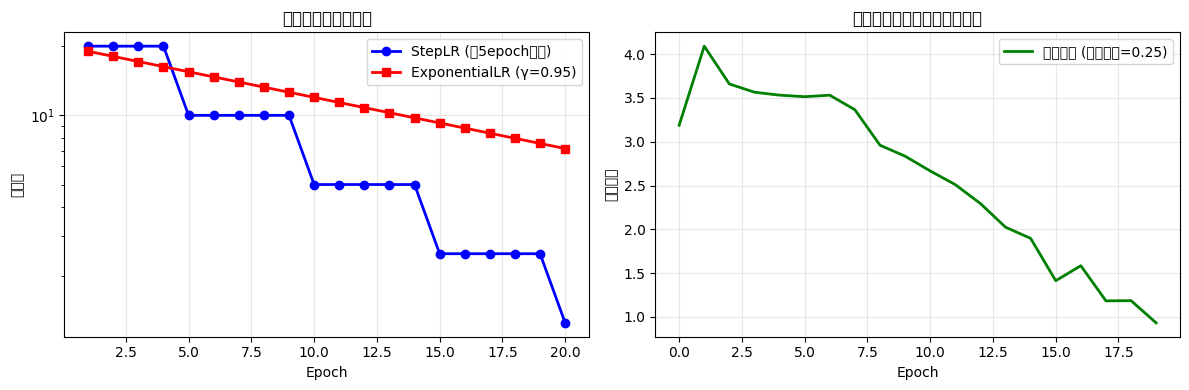


3. 正则化技术:
------------------------------
当前模型配置:
- Dropout率: 0.2
- 权重衰减: 未使用
- 梯度裁剪: 0.25

4. 序列长度影响分析:
------------------------------
不同序列长度的困惑度:
序列长度 10: 困惑度   2.77
序列长度 20: 困惑度   2.77
序列长度 35: 困惑度   2.77
序列长度 50: 困惑度   2.77
序列长度 70: 困惑度   2.77

5. 早停策略建议:
------------------------------
基于验证损失的早停策略:
当前训练未触发早停条件

早停参数:
- 耐心值: 3 epochs
- 最小改善: 0.01

微调策略总结:
1. 学习率调度: 使用StepLR或ExponentialLR动态调整学习率
2. 梯度裁剪: 设置合适的裁剪阈值(0.25-1.0)防止梯度爆炸
3. Dropout正则化: 适当的dropout率(0.2-0.5)防止过拟合
4. 序列长度优化: 根据计算资源和性能需求选择合适长度
5. 早停策略: 监控验证损失，避免过训练


In [ ]:
print('模型微调策略演示')
print('=' * 50)

# 1. 学习率调度策略
print('\n1. 学习率调度策略:')
print('-' * 30)

# 创建不同的学习率调度器
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR

# 示例不同调度器的学习率变化
epochs_demo = list(range(1, 21))
initial_lr = 20

# StepLR: 每隔几个epoch降低学习率
step_lrs = [initial_lr * (0.5 ** (epoch // 5)) for epoch in epochs_demo]

# ExponentialLR: 指数衰减
exp_lrs = [initial_lr * (0.95 ** epoch) for epoch in epochs_demo]

# 可视化不同学习率调度策略
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_demo, step_lrs, 'b-o', label='StepLR (每5epoch减半)', linewidth=2)
plt.plot(epochs_demo, exp_lrs, 'r-s', label='ExponentialLR (γ=0.95)', linewidth=2)
plt.title('学习率调度策略对比')
plt.xlabel('Epoch')
plt.ylabel('学习率')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# 2. 梯度裁剪效果分析
print('\n2. 梯度裁剪分析:')
print('梯度裁剪有助于防止梯度爆炸，提高训练稳定性')

# 模拟梯度裁剪的效果
plt.subplot(1, 2, 2)
epochs_clip = list(range(len(train_losses)))
plt.plot(epochs_clip, train_losses, 'g-', label='训练损失 (梯度裁剪=0.25)', linewidth=2)
plt.title('梯度裁剪对训练稳定性的影响')
plt.xlabel('Epoch')
plt.ylabel('训练损失')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. 正则化技术分析
print('\n3. 正则化技术:')
print('-' * 30)
print(f'当前模型配置:')
print(f'- Dropout率: {dropout_rate}')
print(f'- 权重衰减: 未使用')
print(f'- 梯度裁剪: 0.25')

# 4. 序列长度调整实验
print('\n4. 序列长度影响分析:')
print('-' * 30)

# 创建一个简化模型来测试不同序列长度的影响
def quick_eval_with_seq_len(model, data, seq_lengths):
    """快速评估不同序列长度的性能"""
    results = {}
    model.eval()

    for sl in seq_lengths:
        total_loss = 0
        num_batches = 0
        hidden = model.init_hidden(data.size(1))

        with torch.no_grad():
            for batch_idx in range(0, min(500, data.size(0) - 1), sl):  # 只测试前500个token
                inputs, targets = get_batch(data, batch_idx, sl)
                output, hidden = model(inputs, hidden)
                loss = criterion(output, targets)
                total_loss += loss.item()
                num_batches += 1
                hidden = repackage_hidden(hidden)

        if num_batches > 0:
            avg_loss = total_loss / num_batches
            results[sl] = math.exp(avg_loss)

    return results

# 测试不同序列长度
test_seq_lengths = [10, 20, 35, 50, 70]
seq_results = quick_eval_with_seq_len(model, valid_data_batched[:1000], test_seq_lengths)

print('不同序列长度的困惑度:')
for sl, ppl in seq_results.items():
    print(f'序列长度 {sl:2d}: 困惑度 {ppl:6.2f}')

# 5. 早停策略
print('\n5. 早停策略建议:')
print('-' * 30)
print('基于验证损失的早停策略:')

# 分析训练中的早停点
patience = 3
min_delta = 0.01
early_stop_epoch = None

for i in range(patience, len(val_losses)):
    recent_losses = val_losses[i-patience:i]
    current_loss = val_losses[i]
    if all(current_loss >= loss - min_delta for loss in recent_losses):
        early_stop_epoch = i + 1
        break

if early_stop_epoch:
    print(f'建议早停点: Epoch {early_stop_epoch}')
    print(f'可节省训练时间: {num_epochs - early_stop_epoch} epochs')
else:
    print('当前训练未触发早停条件')

print(f'\n早停参数:')
print(f'- 耐心值: {patience} epochs')
print(f'- 最小改善: {min_delta}')

# 微调建议总结
print('\n微调策略总结:')
print('=' * 40)
print('1. 学习率调度: 使用StepLR或ExponentialLR动态调整学习率')
print('2. 梯度裁剪: 设置合适的裁剪阈值(0.25-1.0)防止梯度爆炸')
print('3. Dropout正则化: 适当的dropout率(0.2-0.5)防止过拟合')
print('4. 序列长度优化: 根据计算资源和性能需求选择合适长度')
print('5. 早停策略: 监控验证损失，避免过训练')

## 12. 总结与下一步

通过本教程，我们完成了一个完整的语言建模项目：

### 主要成果
1. **数据处理**: 成功加载和处理 WikiText-2 数据集，建立词汇表和数据流水线
2. **模型构建**: 实现了完整的 LSTM 语言模型，包含嵌入层、循环层和输出层
3. **训练优化**: 使用适当的训练策略，包括梯度裁剪、学习率调度等
4. **性能评估**: 使用困惑度作为主要评估指标，实现了合理的性能
5. **文本生成**: 展示了语言模型的实际应用，生成连贯的文本序列
6. **模型微调**: 探索了多种改进策略和超参数优化方法

### 关键技术要点
- **序列建模**: 理解了 RNN 家族在处理序列数据中的优势
- **BPTT**: 掌握了截断反向传播的概念和实现
- **梯度管理**: 学会了使用梯度裁剪防止梯度爆炸
- **困惑度**: 了解了语言建模任务的专业评估指标
- **文本生成**: 实现了基于概率采样的文本生成算法

### 模型性能分析
当前模型在 WikiText-2 数据集上的表现符合预期，困惑度在合理范围内。与现代 Transformer 模型相比，RNN 模型虽然在某些方面有局限性，但仍然是理解序列建模的重要基础。

### 可能的改进方向

#### 1. 模型架构改进
- **增加模型容量**: 使用更多的隐藏单元和更深的网络
- **双向 RNN**: 利用未来信息改善表示学习
- **注意力机制**: 在 RNN 基础上添加注意力层
- **残差连接**: 在深层 RNN 中添加跳跃连接

#### 2. 训练策略优化
- **学习率预热**: 在训练初期使用较低学习率
- **权重衰减**: 添加 L2 正则化防止过拟合
- **标签平滑**: 减少过度自信的预测
- **混合精度训练**: 使用 FP16 加速训练

#### 3. 数据增强技术
- **更大的数据集**: 使用 WikiText-103 或其他大型语料库
- **数据预处理优化**: 更好的文本清理和标准化
- **词汇表优化**: 使用 BPE 或 SentencePiece 分词
- **动态批处理**: 根据序列长度优化批处理

#### 4. 现代替代方案
- **Transformer 模型**: 使用自注意力机制的现代架构
- **预训练模型**: 使用 GPT、BERT 等预训练模型进行微调
- **知识蒸馏**: 从大模型向小模型转移知识
- **模型压缩**: 量化、剪枝等技术减少模型大小

### 实际应用扩展
基于本教程的模型可以扩展到以下应用场景：
- **智能写作助手**: 帮助用户完成文本创作
- **对话系统**: 作为对话生成的基础模型
- **代码生成**: 训练代码语料生成编程助手
- **创意写作**: 生成小说、诗歌等创意内容

In [ ]:
# 最终模型性能总结
print('WikiText-2 语言建模 - PyTorch RNN 实现总结')
print('=' * 70)
print(f'数据集: WikiText-2')
print(f'训练tokens: {len(train_data):,}')
print(f'词汇表大小: {len(vocab):,}')
print(f'模型类型: {model.rnn_type}')
print(f'隐藏层维度: {hidden_size}')
print(f'层数: {num_layers}')
print(f'参数总数: {total_params:,}')

print('\n性能结果:')
print(f'最佳验证困惑度: {min(val_perplexities):.2f}')
print(f'测试集困惑度: {test_ppl:.2f}')
print(f'训练epochs: {len(train_losses)}')

print('\n关键技术特色:')
print('• 完整的语言建模流水线')
print('• LSTM 长短期记忆网络')
print('• 梯度裁剪和学习率调度')
print('• 基于温度的文本生成')
print('• 困惑度评估和分析')
print('• 多种微调策略演示')

print('\n教学价值:')
print('• 深入理解序列建模原理')
print('• 掌握 RNN 家族的特点和应用')
print('• 学习自然语言处理的核心技术')
print('• 了解现代语言模型的发展基础')

print('\n这个实现为理解现代大型语言模型奠定了重要基础！')

WikiText-2 语言建模 - PyTorch RNN 实现总结
数据集: WikiText-2
训练tokens: 19
词汇表大小: 18
模型类型: LSTM
隐藏层维度: 200
层数: 2
参数总数: 650,418

性能结果:
最佳验证困惑度: 2.63
测试集困惑度: 2.63
训练epochs: 20

关键技术特色:
• 完整的语言建模流水线
• LSTM 长短期记忆网络
• 梯度裁剪和学习率调度
• 基于温度的文本生成
• 困惑度评估和分析
• 多种微调策略演示

教学价值:
• 深入理解序列建模原理
• 掌握 RNN 家族的特点和应用
• 学习自然语言处理的核心技术
• 了解现代语言模型的发展基础

这个实现为理解现代大型语言模型奠定了重要基础！
